# 依賴倒置原則 (Dependency Inversion Principle, DIP) 

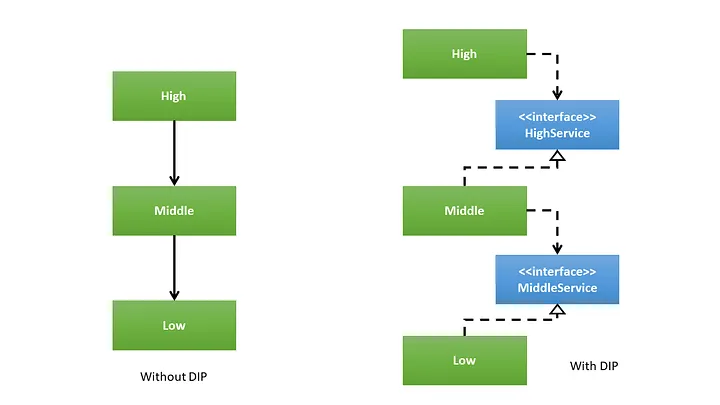

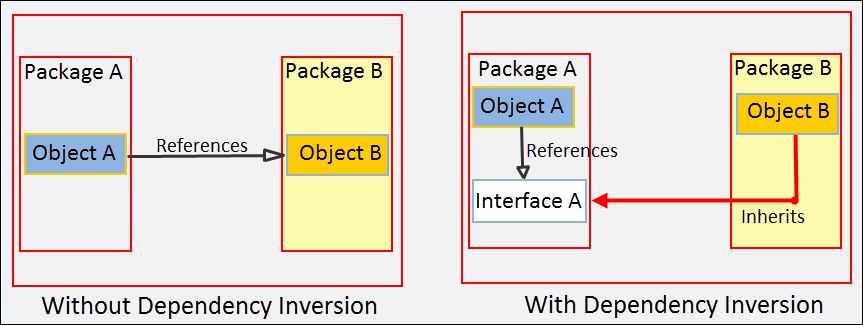

## [ref](https://hyperionnkj.medium.com/software-engineering-principle-dependency-inversion-principle-dip-a46a1a7628da)

## 定義
軟體實體（如類別、模組、函數等）應該對擴展開放，對修改封閉。

## 判斷導入時機

- Do：
當需要為系統添加新功能，而不希望影響現有代碼的穩定性時。
希望通過`擴展`而非修改來適應新需求時。

- Don't：
當過度設計導致不必要的抽象，增加系統複雜性時。


想要降低耦和度時
希望類別都相依於抽象，讓團隊可以有效率的開發系統
先撰寫抽象介面就是把真實世界的需求轉換成類別的過程，規劃出介面後再開始寫類別，定義好介面、方法、API、屬性，先定義好，任何人看到介面就可以開使開發
符合DIP的話通常意味著也符合OCP與LSP原則

當然，如果程式沒有變更的需求，就不會動他拉

大量DIP可能對剛進入團隊的人有障礙。那如果是小系統可能怎麼寫都可以。這裡討論的是稍微大的需求，系統比較複雜，如何讓剛進來的成員快速了解需求掌握系統加入維護開發，可能系統用了很多pattern，新進人員改不動，而用DI可能更容易一些，只剩interface，就只是實做哪個interface的事情，這樣比較好理解，比叫好改，程式碼比較乾淨
我們就怕如果一個需求來，會改到很多地方，那就可以思考重構，看看有什麼改善空間
如果有依據SOLID設計出好的OOP，那最完美的情況是一次只要改一個地方，降低這個class每次更動需要更改數量

----


## 完整案例

### 需求情境

設計一個應用程式，用於與不同的資料庫（如 MySQL 和 SQLite）進行交互。
初始設計中，應用程式直接依賴特定的資料庫實現，導致程式缺乏靈活性，難以適應需求變化。

### 初始設計


In [11]:
class MySQLDatabase:
    def connect(self):
        print("Connecting to MySQL")

class Application:
    def __init__(self):
        self.database = MySQLDatabase()

    def perform_query(self):
        self.database.connect()
        print("Performing query")



> 問題分析

- 直接依賴具體實現：

Application 類別直接依賴於 MySQLDatabase，這是一種高層模組依賴低層模組的設計。
如果需要切換到其他資料庫（如 SQLite），必須修改 Application 類別的代碼。

- 違反 DIP：

高層模組（Application）應該依賴於抽象（如接口或抽象類別），而非具體實現。

- 可測試性低：

測試 Application 時，無法輕鬆替換資料庫實現為測試替身。

### 重構設計
解決方案：引入一個抽象層 Database 作為資料庫交互的接口，具體的資料庫實現（如 MySQL 和 SQLite）繼承該接口。應用程式依賴於抽象，具體實現由依賴注入提供。

In [12]:
from abc import ABC, abstractmethod

# 抽象層 - 資料庫接口
class Database(ABC):
    @abstractmethod
    def connect(self):
        pass

# 具體實現 - MySQL 資料庫
class MySQLDatabase(Database):
    def connect(self):
        print("Connecting to MySQL")

# 具體實現 - SQLite 資料庫
class SQLiteDatabase(Database):
    def connect(self):
        print("Connecting to SQLite")

# 高層模組 - 應用程式
class Application:
    def __init__(self, database: Database):
        self.database = database

    def perform_query(self):
        self.database.connect()
        print("Performing query")


In [13]:
# 使用 MySQL 資料庫
mysql_db = MySQLDatabase()
app = Application(mysql_db)
app.perform_query()

# 切換到 SQLite 資料庫
sqlite_db = SQLiteDatabase()
app = Application(sqlite_db)
app.perform_query()


Connecting to MySQL
Performing query
Connecting to SQLite
Performing query


### 擴展設計
假設需要新增一個新的資料庫類型（如 PostgreSQL），我們只需新增一個類別並實現 Database 接口，而不需要修改 Application 的代碼。

In [14]:
class PostgreSQLDatabase(Database):
    def connect(self):
        print("Connecting to PostgreSQL")

# 使用 PostgreSQL 資料庫
postgresql_db = PostgreSQLDatabase()
app = Application(postgresql_db)
app.perform_query()


Connecting to PostgreSQL
Performing query


### 重構優點

- 高可擴展性：
新增資料庫類型僅需實現 Database 接口，無需修改高層模組的代碼。

- 高可測試性：
可以通過依賴注入輕鬆使用測試替身（mock）。

- 遵循 DIP：
高層模組（Application）和低層模組（資料庫實現）都依賴於抽象（Database 接口）。

- 靈活性提升：
切換資料庫只需替換依賴注入的實例，不影響其他邏輯。

適用場景
- 需要支持多種具體實現（如不同資料庫或外部服務）的應用程式。
- 需要提升系統靈活性，減少高層模組對低層細節的依賴。
- 需要易於測試的高層模組設計。

總結設計脈絡

- SRP：聚焦單一職責，提升代碼可讀性和可測試性。
- OCP：通過抽象實現擴展，避免直接修改已有代碼。
- LSP：確保子類行為與父類一致，增強多態性。
- DIP：引入抽象分離高層業務邏輯與低層技術細節。
- ISP：按需拆分接口，減少不相關功能的耦合。